# CAD-SEL Dataset — Data Cleaning & Audit Notebook

**Policy:** NO datapoints are removed. Anomalies are flagged, logged, and displayed inline for review.

---
## Phase 0: Setup & Imports

In [1]:
import os, sys, glob, warnings, hashlib, json, re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
%matplotlib inline

# --- Paths ---
DATA_ROOT   = Path('data')
IMAGES_DIR  = DATA_ROOT / 'Images'
LABELS_DIR  = DATA_ROOT / 'Labels'
METADATA_XL = DATA_ROOT / 'metadata.xlsx'

# --- Collected anomalies (never remove, only log) ---
anomalies = defaultdict(list)

---
## Phase 1: Structural Integrity Audit

1.1 TIFF readability | 1.2 Zero-byte files | 1.3 Image-label 1:1 pairing | 1.4 Empty label check | 1.5 Naming conventions

In [ ]:
# Collect all image and label paths
all_images = sorted(IMAGES_DIR.rglob('*.tiff'))
all_labels = sorted(LABELS_DIR.rglob('*.txt'))

print(f'Total images found:  {len(all_images)}  (paper expects: 4,912)')
print(f'Total labels found:  {len(all_labels)}')

In [3]:
# 1.1 — TIFF readability + collect shapes
unreadable = []
image_shapes = {}

for p in tqdm(all_images, desc='1.1 TIFF readability'):
    try:
        img = cv2.imread(str(p))
        if img is None:
            raise ValueError('cv2.imread returned None')
        image_shapes[str(p)] = img.shape[:2]  # (H, W)
    except Exception as e:
        unreadable.append((str(p), str(e)))

print(f'Unreadable images: {len(unreadable)}')
anomalies['unreadable_tiff'] = unreadable

Unreadable images: 0


In [4]:
# 1.2 — Zero-byte files
zero_byte_images = [str(p) for p in all_images if p.stat().st_size == 0]
zero_byte_labels = [str(p) for p in all_labels if p.stat().st_size == 0]

print(f'Zero-byte images: {len(zero_byte_images)}')
print(f'Zero-byte labels: {len(zero_byte_labels)}')
anomalies['zero_byte_images'] = zero_byte_images
anomalies['zero_byte_labels'] = zero_byte_labels
# 1.3 — Image-label 1:1 pairing
rel_images = {p.relative_to(IMAGES_DIR).with_suffix('') for p in all_images}
rel_labels = {p.relative_to(LABELS_DIR).with_suffix('') for p in all_labels}

images_without_labels = sorted(rel_images - rel_labels)
labels_without_images = sorted(rel_labels - rel_images)
paired_rel = sorted(rel_images & rel_labels)

print(f'Images without matching label: {len(images_without_labels)}')
print(f'Labels without matching image: {len(labels_without_images)}')
print(f'Valid image-label pairs:   {len(paired_rel)}')
anomalies['images_without_labels'] = images_without_labels
anomalies['labels_without_images'] = labels_without_images
# 1.4 — Labels that contain zero bounding boxes
empty_label_files = []
for rel in tqdm(paired_rel, desc='1.4 Checking empty labels'):
    label_path = LABELS_DIR / f'{rel}.txt'
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    if len(lines) == 0:
        empty_label_files.append(str(rel))

print(f'Empty label files: {len(empty_label_files)}')
anomalies['empty_labels'] = empty_label_files
# 1.5 — Naming convention check
pat_pat = re.compile(r'^(NET_G1|NET_G2|Leiomyoma|Lipoma|NonNeoplasm)-\d+$')
file_pat = re.compile(r'^\d+\.(tiff|txt)$')
naming_anomalies = []

for p in all_images:
    if not pat_pat.match(p.parent.name):
        naming_anomalies.append(('patient_folder', str(p)))
    if not file_pat.match(p.name):
        naming_anomalies.append(('file_name', str(p)))

print(f'Naming anomalies: {len(naming_anomalies)}')
anomalies['naming'] = naming_anomalies

Zero-byte images: 0
Zero-byte labels: 0
Images without matching label: 0
Labels without matching image: 0
Valid image-label pairs:   9824


1.4 Checking empty labels:   0%|          | 0/9824 [00:00<?, ?it/s]

Empty label files: 0
Naming anomalies: 0


In [5]:
# 1.3 — Image-label 1:1 pairing
rel_images = {p.relative_to(IMAGES_DIR).with_suffix('') for p in all_images}
rel_labels = {p.relative_to(LABELS_DIR).with_suffix('') for p in all_labels}

images_without_labels = sorted(rel_images - rel_labels)
labels_without_images = sorted(rel_labels - rel_images)
paired_rel = sorted(rel_images & rel_labels)

print(f'Images without matching label: {len(images_without_labels)}')
print(f'Labels without matching image: {len(labels_without_images)}')
print(f'Valid image-label pairs:   {len(paired_rel)}')
anomalies['images_without_labels'] = images_without_labels
anomalies['labels_without_images'] = labels_without_images

Images without matching label: 0
Labels without matching image: 0
Valid image-label pairs:   9824


In [6]:
# 1.4 — Labels with zero bounding boxes
empty_label_files = []
for rel in tqdm(paired_rel, desc='1.4 Empty labels'):
    with open(LABELS_DIR / f'{rel}.txt') as f:
        if not any(l.strip() for l in f):
            empty_label_files.append(str(rel))

print(f'Empty label files: {len(empty_label_files)}')
anomalies['empty_labels'] = empty_label_files

1.4 Empty labels:   0%|          | 0/9824 [00:00<?, ?it/s]

Empty label files: 0


In [7]:
# 1.5 — Naming convention check
pat_pat = re.compile(r'^(NET_G1|NET_G2|Leiomyoma|Lipoma|NonNeoplasm)-\d+$')
file_pat = re.compile(r'^\d+\.(tiff|txt)$')
naming_anomalies = []

for p in all_images:
    if not pat_pat.match(p.parent.name):
        naming_anomalies.append(('patient_folder', str(p)))
    if not file_pat.match(p.name):
        naming_anomalies.append(('file_name', str(p)))

print(f'Naming anomalies: {len(naming_anomalies)}')
anomalies['naming'] = naming_anomalies

Naming anomalies: 0


---
## Phase 2: Label Quality Audit

2.1 Class ID range | 2.2 Coordinate validity | 2.3 Non-degenerate boxes | 2.4 Box within image bounds | 2.5 Folder-class consistency | 2.6 Class ID mapping

In [8]:
# 2.1-2.4 — Full label audit
all_class_ids = set()
cid_per_cat = defaultdict(set)
label_issues = []

for rel in tqdm(paired_rel, desc='2.1-2.4 Label audit'):
    lbl_path = LABELS_DIR / f'{rel}.txt'
    img_path = IMAGES_DIR / f'{rel}.tiff'
    h, w = image_shapes.get(str(img_path), (0, 0))
    parts = rel.parts  # e.g. ('Center-1', 'WLE-Set', 'NET_G1', 'NET_G1-0', '1')
    category = parts[2] if len(parts) >= 3 else 'unknown'

    with open(lbl_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            vals = line.split()
            if len(vals) != 5:
                label_issues.append(('malformed_line', str(rel), line))
                continue
            try:
                cid = int(float(vals[0]))
                xc, yc, bw, bh = map(float, vals[1:])
            except ValueError:
                label_issues.append(('non_numeric', str(rel), line))
                continue

            all_class_ids.add(cid)
            cid_per_cat[category].add(cid)

            # 2.2 — Coordinate range
            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
                label_issues.append(('coord_oob', str(rel), f'x={xc:.3f} y={yc:.3f} w={bw:.3f} h={bh:.3f}'))

            # 2.3 — Non-degenerate
            if bw <= 0 or bh <= 0:
                label_issues.append(('degenerate_box', str(rel), f'cid={cid} w={bw} h={bh}'))

            # 2.4 — Box within image bounds
            if h > 0 and w > 0:
                x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
                if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
                    label_issues.append(('box_oob', str(rel), f'box=({x1},{y1},{x2},{y2}) img=({w},{h})'))

print(f'Unique class IDs found: {sorted(all_class_ids)}')
print(f'Label issues total:       {len(label_issues)}')
anomalies['label_issues'] = label_issues

2.1-2.4 Label audit:   0%|          | 0/9824 [00:00<?, ?it/s]

Unique class IDs found: [0, 1, 2, 3]
Label issues total:       0


In [9]:
# 2.5-2.6 — Category ↔ class_id mapping
print('=== Category → class_ids ===')
for cat, ids in sorted(cid_per_cat.items()):
    print(f'  {cat:20s} -> {sorted(ids)}')

# Build reverse mapping: class_id → set of categories
cid_to_cats = defaultdict(set)
for cat, ids in cid_per_cat.items():
    for cid in ids:
        cid_to_cats[cid].add(cat)

print('\n=== Definitive Class ID → Category Mapping ===')
for cid in sorted(cid_to_cats):
    cats = cid_to_cats[cid]
    tag = '' if len(cats) == 1 else '  ⚠ AMBIGUOUS'
    print(f'  class_id {cid} -> {", ".join(sorted(cats))}{tag}')

anomalies['ambiguous_class_ids'] = {str(k): list(v) for k, v in cid_to_cats.items() if len(v) > 1}

=== Category → class_ids ===
  Leiomyoma            -> [1, 3]
  Lipoma               -> [2]
  NET_G1               -> [0]
  NET_G2               -> [0]
  NonNeoplasm          -> [3]

=== Definitive Class ID → Category Mapping ===
  class_id 0 -> NET_G1, NET_G2  ⚠ AMBIGUOUS
  class_id 1 -> Leiomyoma
  class_id 2 -> Lipoma
  class_id 3 -> Leiomyoma, NonNeoplasm  ⚠ AMBIGUOUS


---
## Phase 3: Image Quality Audit

3.1 Blur (Laplacian variance) | 3.2 Glare in bbox | 3.3 Brightness extremes | 3.4 Aspect ratio | 3.5 Resolution vs. paper range | 3.6 Grayscale detection

In [10]:
# 3.1 — Blur detection via Laplacian variance
blur_scores = {}
for p in tqdm(all_images, desc='3.1 Blur detection'):
    key = str(p)
    if key not in image_shapes:
        continue
    gray = cv2.imread(key, cv2.IMREAD_GRAYSCALE)
    blur_scores[key] = cv2.Laplacian(gray, cv2.CV_64F).var()

scores = np.array(list(blur_scores.values()))
blur_threshold = np.percentile(scores, 1.0)
blurry = {k: v for k, v in blur_scores.items() if v < blur_threshold}

print(f'Laplacian variance range: {scores.min():.1f} – {scores.max():.1f}')
print(f'Blur threshold (1st percentile): {blur_threshold:.1f}')
print(f'Images below threshold: {len(blurry)}')
anomalies['blurry_images'] = sorted(blurry.items(), key=lambda x: x[1])

3.1 Blur detection:   0%|          | 0/9824 [00:00<?, ?it/s]

Laplacian variance range: 14.6 – 5222.1
Blur threshold (1st percentile): 24.2
Images below threshold: 98


In [11]:
# 3.2 — Glare >50% in bounding box
def glare_in_box(img, xc, yc, bw, bh):
    h_img, w_img = img.shape[:2]
    x1 = max(0, int((xc - bw/2) * w_img))
    y1 = max(0, int((yc - bh/2) * h_img))
    x2 = min(w_img, int((xc + bw/2) * w_img))
    y2 = min(h_img, int((yc + bh/2) * h_img))
    if x2 <= x1 or y2 <= y1:
        return 0.0
    patch = img[y1:y2, x1:x2]
    if patch.size == 0:
        return 0.0
    return np.any(patch > 250, axis=-1).mean()

glare_anomalies = []
for rel in tqdm(paired_rel, desc='3.2 Glare detection'):
    img_path = IMAGES_DIR / f'{rel}.tiff'
    key = str(img_path)
    if key not in image_shapes:
        continue
    img = cv2.imread(key)
    if img is None:
        continue
    with open(LABELS_DIR / f'{rel}.txt') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            vals = line.split()
            if len(vals) != 5:
                continue
            cid, xc, yc, bw, bh = int(float(vals[0])), *map(float, vals[1:])
            frac = glare_in_box(img, xc, yc, bw, bh)
            if frac > 0.5:
                glare_anomalies.append((str(rel), int(cid), frac))

print(f'Images with >50% glare in bbox: {len(glare_anomalies)}')
anomalies['glare_in_bbox'] = glare_anomalies

3.2 Glare detection:   0%|          | 0/9824 [00:00<?, ?it/s]

Images with >50% glare in bbox: 100


In [12]:
# 3.3 — Near-black / near-white images
ext_bright = []
for p in tqdm(all_images, desc='3.3 Brightness extremes'):
    key = str(p)
    if key not in image_shapes:
        continue
    mean_val = cv2.imread(key).mean()
    if mean_val < 10 or mean_val > 245:
        ext_bright.append((key, mean_val))

print(f'Near-black (<10 mean): {sum(1 for _, v in ext_bright if v < 10)}')
print(f'Near-white (>245 mean): {sum(1 for _, v in ext_bright if v > 245)}')
anomalies['extreme_brightness'] = ext_bright

3.3 Brightness extremes:   0%|          | 0/9824 [00:00<?, ?it/s]

Near-black (<10 mean): 178
Near-white (>245 mean): 0


In [13]:
# 3.4 — Aspect ratio outliers
ar_out = []
for key, (h, w) in image_shapes.items():
    ar = w / h if h > 0 else 0
    if ar > 3.0 or ar < 1/3.0:
        ar_out.append((key, w, h, ar))

print(f'Aspect ratio outliers (>3:1 or <1:3): {len(ar_out)}')
anomalies['aspect_ratio_outliers'] = ar_out

Aspect ratio outliers (>3:1 or <1:3): 0


Resolution — Width:  362–1920  median: 1160
Resolution — Height: 290–1080 median: 1008
Paper range outliers: 0


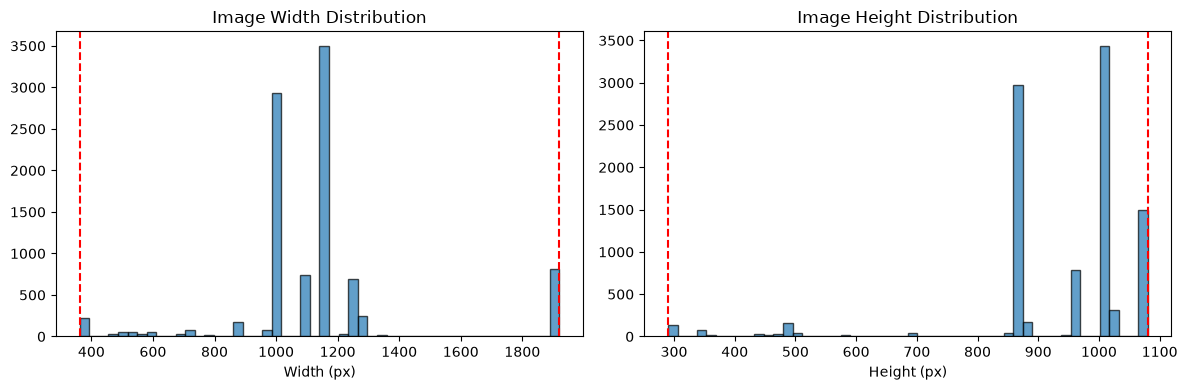

In [14]:
# 3.5 — Resolution vs. paper range (362×290 – 1920×1080)
res_out = []
all_heights, all_widths = [], []
for key, (h, w) in image_shapes.items():
    all_heights.append(h)
    all_widths.append(w)
    if w < 362 or h < 290 or w > 1920 or h > 1080:
        res_out.append((key, w, h))

all_heights = np.array(all_heights)
all_widths  = np.array(all_widths)
print(f'Resolution — Width:  {all_widths.min()}–{all_widths.max()}  median: {np.median(all_widths):.0f}')
print(f'Resolution — Height: {all_heights.min()}–{all_heights.max()} median: {np.median(all_heights):.0f}')
print(f'Paper range outliers: {len(res_out)}')
anomalies['resolution_outliers'] = res_out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(all_widths, bins=50, edgecolor='k', alpha=0.7)
ax1.axvline(x=362, color='r', linestyle='--', label='Paper min')
ax1.axvline(x=1920, color='r', linestyle='--', label='Paper max')
ax1.set_xlabel('Width (px)'); ax1.set_title('Image Width Distribution')
ax2.hist(all_heights, bins=50, edgecolor='k', alpha=0.7)
ax2.axvline(x=290, color='r', linestyle='--')
ax2.axvline(x=1080, color='r', linestyle='--')
ax2.set_xlabel('Height (px)'); ax2.set_title('Image Height Distribution')
plt.tight_layout(); plt.show()

In [15]:
# 3.6 — Grayscale image detection
gray_imgs = []
for p in tqdm(all_images, desc='3.6 Grayscale check'):
    key = str(p)
    if key not in image_shapes:
        continue
    img = cv2.imread(key)
    if img.ndim == 2:
        gray_imgs.append((key, 'single_channel'))
    elif img.ndim == 3 and img.shape[2] == 3:
        if np.array_equal(img[:,:,0], img[:,:,1]) and np.array_equal(img[:,:,1], img[:,:,2]):
            gray_imgs.append((key, '3ch_identical'))

print(f'Grayscale images: {len(gray_imgs)}')
anomalies['grayscale_images'] = gray_imgs

3.6 Grayscale check:   0%|          | 0/9824 [00:00<?, ?it/s]

Grayscale images: 2900


---
## Phase 4: Metadata Cross-Validation

4.1-4.2 File-system vs. Table 2 | 4.3 Metadata vs. filesystem patients | 4.4 EUS flag audit | 4.5 Center distribution | 4.6 Age/sex sanity

In [ ]:
# Load metadata
df = pd.read_excel(METADATA_XL)
print(f'Metadata rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

: 

In [ ]:
# 4.1-4.2 — File-system counts vs. paper Table 2
fs = defaultdict(lambda: {'patients': set(), 'images': 0})
for tiff in IMAGES_DIR.rglob('*.tiff'):
    parts = tiff.relative_to(IMAGES_DIR).parts
    if len(parts) >= 5 and parts[0].startswith('Center'):
        key = (parts[1], parts[2])  # (modality, category)
        fs[key]['patients'].add(parts[3])
        fs[key]['images'] += 1

# Paper Table 2
paper_t2 = {
    ('WLE-Set', 'NET_G1'): (411, 1749), ('WLE-Set', 'NET_G2'): (44, 196),
    ('WLE-Set', 'Lipoma'): (96, 453), ('WLE-Set', 'Leiomyoma'): (24, 137),
    ('WLE-Set', 'NonNeoplasm'): (66, 282),
    ('EUS-Set', 'NET_G1'): (299, 1444), ('EUS-Set', 'NET_G2'): (26, 158),
    ('EUS-Set', 'Lipoma'): (49, 254), ('EUS-Set', 'Leiomyoma'): (14, 79),
    ('EUS-Set', 'NonNeoplasm'): (33, 160),
}

disc = []
print(f'{"Modality":<10} {"Category":<14} {"Pat(fs)":>8} {"Pat(exp)":>10} {"Img(fs)":>8} {"Img(exp)":>10} S')
print('-' * 70)
for (mod, cat), (ep, ei) in sorted(paper_t2.items()):
    d = fs.get((mod, cat), {'patients': set(), 'images': 0})
    ok = len(d['patients']) == ep and d['images'] == ei
    print(f'{mod:<10} {cat:<14} {len(d["patients"]):>8} {ep:>10} {d["images"]:>8} {ei:>10} {"✓" if ok else "⚠"}')
    if not ok:
        disc.append((mod, cat, len(d['patients']), ep, d['images'], ei))

anomalies['table2_discrepancies'] = disc

In [ ]:
# 4.3 — Metadata vs filesystem patient lists
name_col = 'Name' if 'Name' in df.columns else 'Patient ID'
meta_pts = set(df[name_col].astype(str))
fs_pts = set()
for d in fs.values():
    fs_pts.update(d['patients'])

meta_only = meta_pts - fs_pts
fs_only = fs_pts - meta_pts
print(f'Patients in metadata only: {len(meta_only)}')
print(f'Patients in filesystem only: {len(fs_only)}')
anomalies['meta_only_patients'] = sorted(meta_only)
anomalies['fs_only_patients'] = sorted(fs_only)

# 4.4 — EUS flag vs. actual EUS data
eus_col = next((c for c in df.columns if 'eus' in c.lower()), None)
if eus_col:
    df[eus_col] = pd.to_numeric(df[eus_col], errors='coerce')
    eus_exp = set(df[df[eus_col] == 1][name_col].astype(str))
    eus_act = set()
    for (mod, _), d in fs.items():
        if mod == 'EUS-Set':
            eus_act.update(d['patients'])
    print(f'\nEUS flag=1 but no EUS images: {len(eus_exp - eus_act)}')
    print(f'EUS images exist but flag≠1:  {len(eus_act - eus_exp)}')
    anomalies['eus_flag_missing'] = sorted(eus_exp - eus_act)
    anomalies['eus_flag_extra'] = sorted(eus_act - eus_exp)

# 4.5-4.6 — Center distribution & age/sex sanity
if 'Center' in df.columns:
    print(f'\n=== Patients per Center ===\n{df["Center"].value_counts().to_string()}')
age_col = next((c for c in df.columns if 'age' in c.lower()), None)
if age_col:
    df[age_col] = pd.to_numeric(df[age_col], errors='coerce')
    bad_age = df[(df[age_col] < 18) | (df[age_col] > 100)]
    print(f'\nAge outliers (<18 or >100): {len(bad_age)}')
    print(f'Age: mean={df[age_col].mean():.1f} median={df[age_col].median():.0f} range={df[age_col].min():.0f}–{df[age_col].max():.0f}')
sex_col = next((c for c in df.columns if 'sex' in c.lower()), None)
if sex_col:
    print(f'\nSex distribution:\n{df[sex_col].value_counts().to_string()}')

---
## Phase 5: Cross-Center & Cross-Modality Integrity

5.1 Patient leakage | 5.2 MD5 duplicates | 5.3 WLE↔EUS patient overlap | 5.4 Center class coverage | 5.5 Modality balance

In [ ]:
# 5.1 — Patient leakage across centers
pt_centers = defaultdict(set)
for p in all_images:
    parts = p.relative_to(IMAGES_DIR).parts
    if len(parts) >= 4 and parts[0].startswith('Center'):
        pt_centers[parts[3]].add(parts[0])

leaked = {p: c for p, c in pt_centers.items() if len(c) > 1}
print(f'Cross-center patient leakage: {len(leaked)}')
if leaked:
    for pat, centers in sorted(leaked.items()):
        print(f'  {pat}: {centers}')
anomalies['cross_center_leakage'] = {str(k): list(v) for k, v in leaked.items()}

In [ ]:
# 5.2 — MD5 duplicates
hash_map = defaultdict(list)
for p in tqdm(all_images, desc='5.2 MD5 hashing'):
    try:
        with open(p, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        hash_map[file_hash].append(str(p))
    except Exception:
        pass

dups = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
dup_total = sum(len(v) for v in dups.values())
print(f'MD5 duplicate groups: {len(dups)} (total files: {dup_total})')
anomalies['md5_duplicates'] = {h: paths for h, paths in list(dups.items())[:20]}

In [ ]:
# 5.3-5.4-5.5 — WLE↔EUS overlap + center coverage + modality balance
print('=== WLE↔EUS Patient Overlap per Center ===')
for cd in sorted(IMAGES_DIR.glob('Center-*')):
    wle_pts = set()
    eus_pts = set()
    if (cd / 'WLE-Set').exists():
        wle_pts = {d.name for d in (cd / 'WLE-Set').rglob('*') if d.is_dir() and d.parent.parent.name == 'WLE-Set'}
    if (cd / 'EUS-Set').exists():
        eus_pts = {d.name for d in (cd / 'EUS-Set').rglob('*') if d.is_dir() and d.parent.parent.name == 'EUS-Set'}
    print(f'{cd.name}: WLE={len(wle_pts)} EUS={len(eus_pts)} paired={len(wle_pts & eus_pts)} wle-only={len(wle_pts - eus_pts)} eus-only={len(eus_pts - wle_pts)}')

print('\n=== Center Class Coverage ===')
all_cats = ['NET_G1', 'NET_G2', 'Leiomyoma', 'Lipoma', 'NonNeoplasm']
for cd in sorted(IMAGES_DIR.glob('Center-*')):
    for mod in ['WLE-Set', 'EUS-Set']:
        mp = cd / mod
        if mp.exists():
            present = [d.name for d in mp.iterdir() if d.is_dir()]
            missing = [c for c in all_cats if c not in present]
            if missing:
                print(f'{cd.name}/{mod}  MISSING: {missing}')

print('\n=== WLE:EUS Image Ratio per Class ===')
mod_cnt = defaultdict(lambda: {'WLE': 0, 'EUS': 0})
for p in all_images:
    parts = p.relative_to(IMAGES_DIR).parts
    if len(parts) >= 5 and parts[0].startswith('Center'):
        mod_cnt[parts[2]]['WLE' if parts[1] == 'WLE-Set' else 'EUS'] += 1
print(f'{"Category":<14} {"WLE":>6} {"EUS":>6} {"WLE:EUS":>10}')
print('-' * 38)
for cat in sorted(mod_cnt):
    w, e = mod_cnt[cat]['WLE'], mod_cnt[cat]['EUS']
    ratio = f'{w/e:.2f}' if e > 0 else '∞'
    print(f'{cat:<14} {w:>6} {e:>6} {ratio:>10}')

---
## Phase 6: Gapped File Numbering Investigation

In [ ]:
# 6.1 — Catalog all numbering gaps
def find_gaps(nums):
    nums = sorted(nums)
    return [(nums[i]+1, nums[i+1]-1) for i in range(len(nums)-1) if nums[i+1]-nums[i] > 1]

gapped = {}
for p in all_images:
    pd = p.parent
    nums = [int(f.stem) for f in pd.glob('*.tiff')]
    g = find_gaps(nums)
    if g:
        gapped[str(pd.relative_to(IMAGES_DIR))] = {'present': sorted(nums), 'gaps': g}

total_ranges = sum(len(v['gaps']) for v in gapped.values())
total_missing = sum(b-a+1 for v in gapped.values() for a, b in v['gaps'])
print(f'Patient folders with gapped numbering: {len(gapped)}')
print(f'Total gap ranges: {total_ranges}')
print(f'Total missing numbers: {total_missing}')
anomalies['gapped_numbering_count'] = len(gapped)

# 6.3 — Verify labels follow same gap pattern
lbl_gap_mismatch = []
for p in all_images:
    pd_rel = p.parent.relative_to(IMAGES_DIR)
    img_nums = {int(f.stem) for f in p.parent.glob('*.tiff')}
    lbl_dir = LABELS_DIR / pd_rel
    if lbl_dir.exists():
        lbl_nums = {int(f.stem) for f in lbl_dir.glob('*.txt')}
        if img_nums != lbl_nums:
            lbl_gap_mismatch.append((str(pd_rel), sorted(img_nums - lbl_nums), sorted(lbl_nums - img_nums)))

print(f'Image-label gap mismatches: {len(lbl_gap_mismatch)}')
anomalies['label_gap_mismatch'] = lbl_gap_mismatch

---
## Phase 7: WLE ↔ EUS Image Correspondence Verification

For every patient appearing in both WLE-Set and EUS-Set within the same center, verify both modalities exist, compare image counts, dimensions, and display side-by-side with bounding boxes.

In [ ]:
# 7.1 — Build WLE↔EUS patient index
pt_mods = defaultdict(lambda: {'WLE': [], 'EUS': []})

for rel in paired_rel:
    parts = rel.parts  # ('Center-1', 'WLE-Set', 'NET_G1', 'NET_G1-0', '1')
    if len(parts) < 5 or not parts[0].startswith('Center'):
        continue
    modality = 'WLE' if parts[1] == 'WLE-Set' else 'EUS'
    pt_mods[(parts[0], parts[3])][modality].append(rel)

paired_pts = []
wle_only_pts = []
eus_only_pts = []

for (c, p), mods in sorted(pt_mods.items()):
    if mods['WLE'] and mods['EUS']:
        paired_pts.append((c, p, len(mods['WLE']), len(mods['EUS'])))
    elif mods['WLE']:
        wle_only_pts.append((c, p, len(mods['WLE'])))
    elif mods['EUS']:
        eus_only_pts.append((c, p, len(mods['EUS'])))

print(f'Patients with BOTH WLE+EUS:  {len(paired_pts)}')
print(f'Patients with WLE only:      {len(wle_only_pts)}')
print(f'Patients with EUS only:      {len(eus_only_pts)}')
anomalies['wle_only'] = wle_only_pts
anomalies['eus_only'] = eus_only_pts
anomalies['paired'] = paired_pts

In [ ]:
# 7.2 — Per-center WLE↔EUS summary
from collections import Counter
cp = defaultdict(lambda: {'paired': 0, 'wle_only': 0, 'eus_only': 0})
for c, p, _, _ in paired_pts:
    cp[c]['paired'] += 1
for c, p, _ in wle_only_pts:
    cp[c]['wle_only'] += 1
for c, p, _ in eus_only_pts:
    cp[c]['eus_only'] += 1

print(f'{"Center":<10} {"Paired":>8} {"WLE-only":>10} {"EUS-only":>10}')
print('-' * 42)
for c in sorted(cp):
    print(f'{c:<10} {cp[c]["paired"]:>8} {cp[c]["wle_only"]:>10} {cp[c]["eus_only"]:>10}')

# 7.3 — WLE↔EUS count disparity (>5×)
disp = [(c, p, w, e, max(w, e) / max(min(w, e), 1)) for c, p, w, e in paired_pts]
disp_big = [d for d in disp if d[4] > 5]
print(f'\nPatients with >5× WLE/EUS image count disparity: {len(disp_big)}')
for c, p, w, e, r in disp_big:
    print(f'  {c}/{p}: WLE={w} EUS={e} ratio={r:.1f}×')
anomalies['wle_eus_count_disparity'] = disp_big

In [ ]:
# 7.4 — WLE↔EUS visual side-by-side comparison with bounding boxes
N_DISPLAY = 12

def load_rgb(rel):
    img = cv2.imread(str(IMAGES_DIR / f'{rel}.tiff'))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else None

def draw_boxes(img, rel):
    lbl = LABELS_DIR / f'{rel}.txt'
    if not lbl.exists():
        return img
    h, w = img.shape[:2]
    for line in open(lbl):
        line = line.strip()
        if not line:
            continue
        vals = line.split()
        if len(vals) != 5:
            continue
        cid, xc, yc, bw, bh = int(float(vals[0])), *map(float, vals[1:])
        x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img, f'cls {int(cid)}', (x1, max(y1-5, 15)),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return img

# Pick random sample
np.random.seed(42)
sample = [paired_pts[i] for i in np.random.choice(len(paired_pts), min(N_DISPLAY, len(paired_pts)), replace=False)]

fig, axes = plt.subplots(N_DISPLAY, 2, figsize=(12, 4 * N_DISPLAY))
if N_DISPLAY == 1:
    axes = axes.reshape(1, 2)

for row, (c, p, nw, ne) in enumerate(sample):
    wle_rel = pt_mods[(c, p)]['WLE'][0]
    eus_rel = pt_mods[(c, p)]['EUS'][0]

    wle_img = load_rgb(wle_rel)
    eus_img = load_rgb(eus_rel)

    if wle_img is not None:
        axes[row, 0].imshow(draw_boxes(wle_img, wle_rel))
    axes[row, 0].set_title(f'{c} | {p}\nWLE ({nw} imgs)', fontsize=10)
    axes[row, 0].axis('off')

    if eus_img is not None:
        axes[row, 1].imshow(draw_boxes(eus_img, eus_rel))
    axes[row, 1].set_title(f'{c} | {p}\nEUS ({ne} imgs)', fontsize=10)
    axes[row, 1].axis('off')

plt.suptitle('WLE ↔ EUS Side-by-Side Comparison (with bounding boxes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# 7.5 — WLE vs EUS dimension comparison
dim_pairs = []
for c, p, _, _ in paired_pts:
    wle_rel = pt_mods[(c, p)]['WLE'][0]
    eus_rel = pt_mods[(c, p)]['EUS'][0]
    ws = image_shapes.get(str(IMAGES_DIR / f'{wle_rel}.tiff'))
    es = image_shapes.get(str(IMAGES_DIR / f'{eus_rel}.tiff'))
    if ws and es:
        dim_pairs.append((c, p, ws, es))

wle_h = np.array([d[2][0] for d in dim_pairs])
wle_w = np.array([d[2][1] for d in dim_pairs])
eus_h = np.array([d[3][0] for d in dim_pairs])
eus_w = np.array([d[3][1] for d in dim_pairs])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(wle_w, wle_h, alpha=0.3, s=8, label='WLE')
axes[0].scatter(eus_w, eus_h, alpha=0.3, s=8, label='EUS', marker='^')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Height (px)')
axes[0].set_title('WLE vs EUS Image Dimensions'); axes[0].legend()

ar_wle = wle_w / np.maximum(wle_h, 1)
ar_eus = eus_w / np.maximum(eus_h, 1)
axes[1].hist(ar_wle, bins=40, alpha=0.5, label='WLE')
axes[1].hist(ar_eus, bins=40, alpha=0.5, label='EUS')
axes[1].set_xlabel('Aspect Ratio (W/H)'); axes[1].set_title('Aspect Ratio Distribution')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f'WLE median dimensions: {np.median(wle_w):.0f}×{np.median(wle_h):.0f}')
print(f'EUS median dimensions: {np.median(eus_w):.0f}×{np.median(eus_h):.0f}')

---
## Phase 8: Display Anomalous Images

Render flagged images inline: blurriest, glare, extreme brightness, aspect ratio outliers, grayscale.

In [ ]:
# 8.1 — Blurriest images
N = 8
blurry_sorted = sorted(blur_scores.items(), key=lambda x: x[1])[:N]
fig, axes = plt.subplots(1, N, figsize=(4*N, 4))
for ax, (path, score) in zip(axes, blurry_sorted):
    img = cv2.imread(path)
    if img is not None:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Blur: {score:.1f}', fontsize=9)
    ax.axis('off')
plt.suptitle(f'Top {N} Blurriest Images (lowest Laplacian variance)')
plt.tight_layout(); plt.show()

In [ ]:
# 8.2 — Glare images
N = 8
if glare_anomalies:
    dg = glare_anomalies[:N]
    fig, axes = plt.subplots(1, min(N, len(dg)), figsize=(4*min(N, len(dg)), 4))
    if len(dg) == 1:
        axes = [axes]
    for ax, (rel, cid, frac) in zip(axes, dg):
        img = cv2.imread(str(IMAGES_DIR / f'{rel}.tiff'))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Glare {frac:.0%} cls={cid}', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'Glare >50% in Bounding Box (first {min(N, len(glare_anomalies))})')
    plt.tight_layout(); plt.show()
else:
    print('No glare anomalies found.')

In [ ]:
# 8.3 — Extreme brightness images
N = 8
if ext_bright:
    dg = ext_bright[:N]
    fig, axes = plt.subplots(1, min(N, len(dg)), figsize=(4*min(N, len(dg)), 4))
    if len(dg) == 1:
        axes = [axes]
    for ax, (path, mean_val) in zip(axes, dg):
        img = cv2.imread(path)
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        label = 'Dark' if mean_val < 10 else 'Bright'
        ax.set_title(f'{label}: mean={mean_val:.1f}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Extreme Brightness Images')
    plt.tight_layout(); plt.show()
else:
    print('No extreme brightness images found.')

In [ ]:
# 8.4 — Aspect ratio outliers
N = 8
if ar_out:
    dg = ar_out[:N]
    fig, axes = plt.subplots(1, min(N, len(dg)), figsize=(4*min(N, len(dg)), 4))
    if len(dg) == 1:
        axes = [axes]
    for ax, (path, w, h, ar) in zip(axes, dg):
        img = cv2.imread(path)
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{w}×{h} AR={ar:.2f}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Aspect Ratio Outliers (>3:1 or <1:3)')
    plt.tight_layout(); plt.show()
else:
    print('No aspect ratio outliers found.')

# 8.5 — Grayscale images
N = 8
if gray_imgs:
    dg = gray_imgs[:N]
    fig, axes = plt.subplots(1, min(N, len(dg)), figsize=(4*min(N, len(dg)), 4))
    if len(dg) == 1:
        axes = [axes]
    for ax, (path, reason) in zip(axes, dg):
        img = cv2.imread(path)
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(reason, fontsize=9)
        ax.axis('off')
    plt.suptitle('Grayscale / Single-Channel Images')
    plt.tight_layout(); plt.show()
else:
    print('No grayscale images found.')

---
## Phase 9: Summary Report

In [ ]:
print('=' * 70)
print('CAD-SEL DATA CLEANING — SUMMARY REPORT')
print('=' * 70)
print(f'\nTotal images on disk:        {len(all_images)}  (paper: 4,912)')
print(f'Total labels on disk:         {len(all_labels)}')
print(f'Valid image-label pairs:      {len(paired_rel)}')
print(f'Paired WLE+EUS patients:      {len(paired_pts)}')
print(f'WLE-only patients:            {len(wle_only_pts)}')
print(f'EUS-only patients:            {len(eus_only_pts)}')

print(f'\n--- Anomaly Counts (ZERO data removed) ---')
for key, val in anomalies.items():
    count = len(val) if isinstance(val, (list, dict, set)) else 0
    if count > 0:
        print(f'  {key:<35s}: {count}')

print(f'\n--- Distribution ---')
print(f'Gapped folders: {len(gapped)}')
if dups:
    print(f'MD5 duplicate groups: {len(dups)}')
if leaked:
    print(f'Cross-center leakage: {len(leaked)} patients')
for issue_type in set(t for t, _, _ in label_issues):
    count = sum(1 for t, _, _ in label_issues if t == issue_type)
    print(f'Label issue [{issue_type}]: {count}')

print('\n' + '=' * 70)
print('CLEANING COMPLETE — All anomalies logged. Zero datapoints removed.')
print('=' * 70)

In [ ]:
# Export anomalies to JSON
def serialize(obj):
    if isinstance(obj, dict):
        return {str(k): serialize(v) for k, v in obj.items()}
    if isinstance(obj, set):
        return sorted(str(x) for x in obj)
    if isinstance(obj, list):
        return [str(x) for x in obj]
    return str(obj)

with open('data_cleaning_anomalies.json', 'w') as f:
    json.dump(serialize(anomalies), f, indent=2)

print('Anomalies saved to: data_cleaning_anomalies.json')